In [45]:
import kagglehub
fedesoriano_stellar_classification_dataset_sdss17_path = kagglehub.dataset_download('fedesoriano/stellar-classification-dataset-sdss17')

print('Data source import complete.')


Using Colab cache for faster access to the 'stellar-classification-dataset-sdss17' dataset.
Data source import complete.


In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/stellar-classification-dataset-sdss17/star_classification.csv


In [ ]:
df = pd.read_csv("/kaggle/input/stellar-classification-dataset-sdss17/star_classification.csv")

In [ ]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [ ]:
df.info() #analysing data and its features

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [ ]:
df['class'].value_counts() #determining if the data is balanced

,count
class,
GALAXY,59445
STAR,21594
QSO,18961


In [ ]:
df["class"]=[0 if i == "GALAXY" else 1 if i == "STAR" else 2 for i in df["class"]] # encoding the classes with numerical integers

/tmp/ipykernel_7449/629218142.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x = df["class"], palette="Set3")


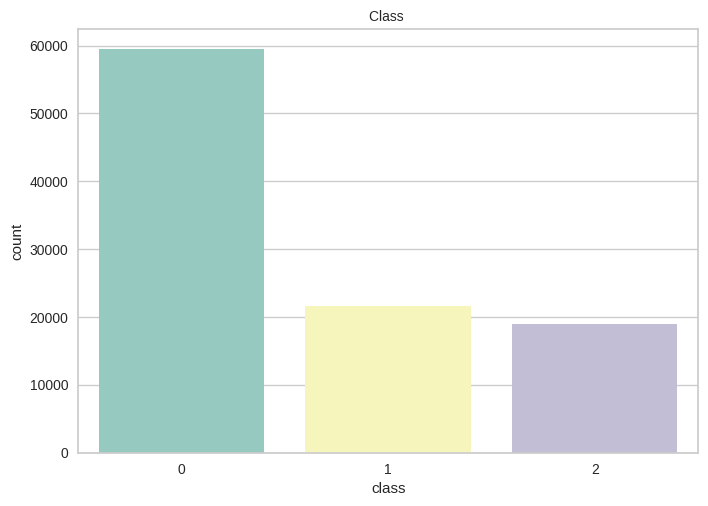

In [ ]:
sns.countplot(df, x = df["class"], palette="Set3")
plt.title("Class ",fontsize=10)
plt.show()

**Detecting Outliers**

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
clf = LocalOutlierFactor()
y_pred = clf.fit_predict(df)

In [ ]:
x_score = clf.negative_outlier_factor_
outlier_score = pd.DataFrame()
outlier_score["score"] = x_score

threshold2 = -1.5 #choosing the factor for the best accuracy obtained.
filtre2 = outlier_score["score"] < threshold2
outlier_index = outlier_score[filtre2].index.tolist() #creating list of outlier indices

In [ ]:
len(outlier_index)

15256

In [ ]:
df = df.drop(index=outlier_index, axis = 0) #dropping outlier rows

Feature Selection

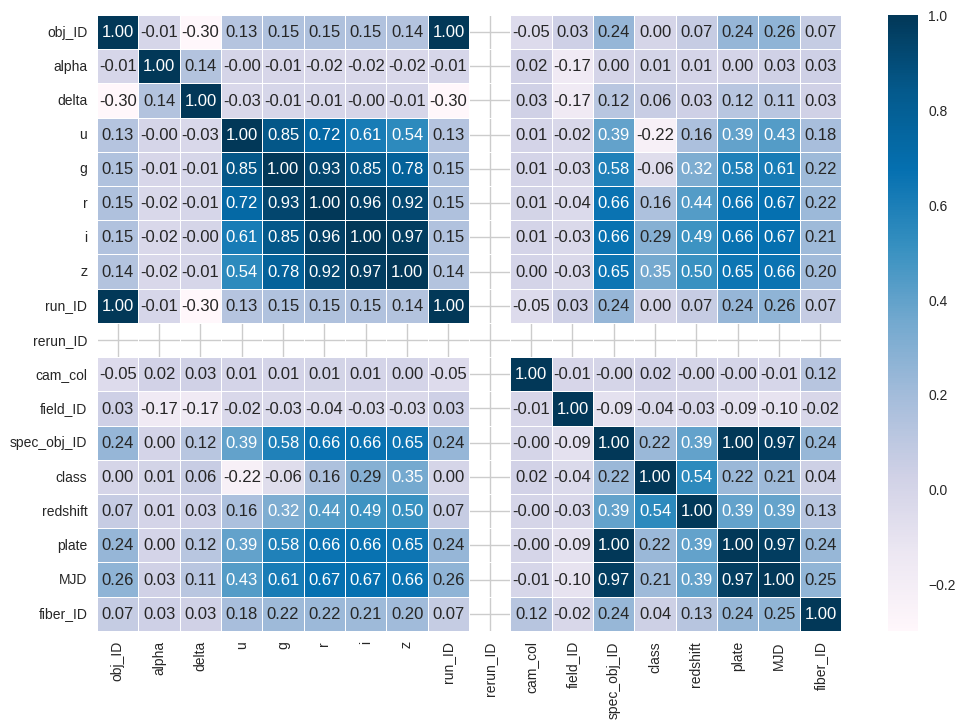

In [ ]:
f,ax = plt.subplots(figsize=(12,8))
sns.heatmap(df.corr(), cmap="PuBu", annot=True, linewidths=0.5, fmt= '.2f',ax=ax)
plt.show() #correlation map for feature selection

In [ ]:
corr = df.corr()

In [ ]:
corr["class"].sort_values()

,class
u,-0.222802
g,-0.058192
field_ID,-0.037542
run_ID,0.000250
obj_ID,0.000252
alpha,0.008187
cam_col,0.017789
fiber_ID,0.037319
delta,0.058947
r,0.160654


In [ ]:
df = df.drop(['obj_ID','alpha','delta','run_ID','rerun_ID','cam_col','field_ID','fiber_ID'], axis = 1) #eliminating unnecessary features

Balancing the Data

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [ ]:
x = df.drop(['class'], axis = 1)
y = df.loc[:,'class'].values

In [ ]:
sm = SMOTE(random_state=42)
print('Original dataset shape %s' % Counter(y))
x, y = sm.fit_resample(x, y)
print('Resampled dataset shape %s' % Counter(y)) # the data is now properly balanced between all three classes

Original dataset shape Counter({np.int64(0): 50695, np.int64(1): 17890, np.int64(2): 16159})
Resampled dataset shape Counter({np.int64(0): 50695, np.int64(2): 50695, np.int64(1): 50695})


In [ ]:
sns.countplot(y, palette='Set3')
plt.title("Class ",fontsize=10)
plt.show()

Scaling the Data

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x)
x = scaler.transform(x) #scaling the data

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np #importing necessary libraries

Train - Test Split

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.33, random_state = 42)

Hyperparameter tuning using GridSearch CV

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [25, 100],
    'max_depth': [4, 6, 10],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
} #grid of hyperparameters to find the best optimum fit model with low bias and low variance.

In [ ]:
grid_search = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)


In [ ]:
grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

In [47]:
model = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    max_depth=6,
    max_leaf_nodes=6
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(classification_report(y_pred, y_test))

score = model.score(x_test, y_test)
accuracy = np.mean(score)

print(f'The accuracy of the model is: {accuracy*100}%')
#random forest classifier is run with the previously calculated hyperparameters for precise and acccurate results

              precision    recall  f1-score   support

           0       0.93      0.93      0.93     16599
           1       1.00      0.99      1.00     16838
           2       0.93      0.94      0.93     16752

    accuracy                           0.95     50189
   macro avg       0.95      0.95      0.95     50189
weighted avg       0.95      0.95      0.95     50189

The accuracy of the model is: 95.34160871904203%


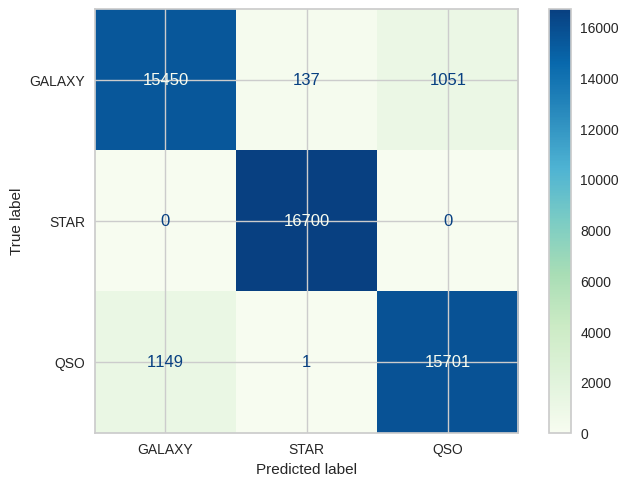

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(model,
    x_test,
    y_test,
    labels=[0, 1, 2],
    display_labels=['GALAXY', 'STAR', 'QSO'],
    cmap='GnBu'
)
#the confusion matrix displays that most of the celestial objects have been classfied correctly.

ROC AUC Score : 0.9983592522269165


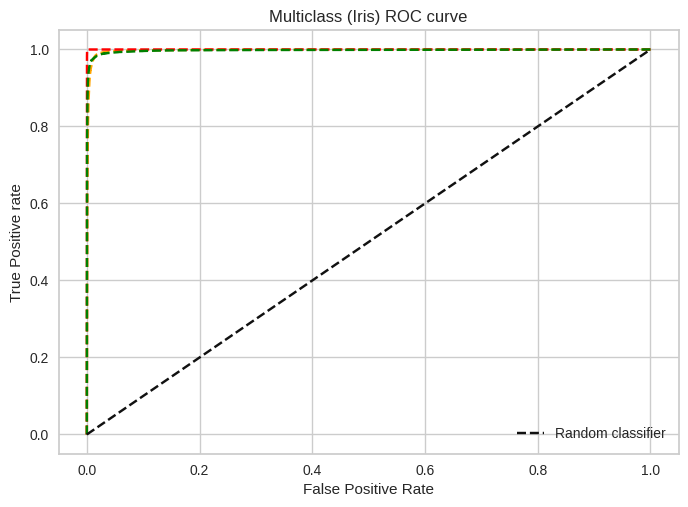

In [49]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.datasets import load_iris
from sklearn.multiclass import OneVsRestClassifier

iris = load_iris()

clf = OneVsRestClassifier(RandomForestClassifier())

clf.fit(x_train, y_train)

y_pred_prob = clf.predict_proba(x_test)

roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print('ROC AUC Score :',roc_auc)

colors = ['orange','red','green']
for i in range(len(iris.target_names)):
    fpr, tpr, thresh = roc_curve(y_test, y_pred_prob[:,i], pos_label=i)
    plt.plot(fpr, tpr, linestyle='--',color=colors[i])
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.title('Multiclass (Iris) ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend()
plt.show() #roc-auc curve is plotted (one vs rest)

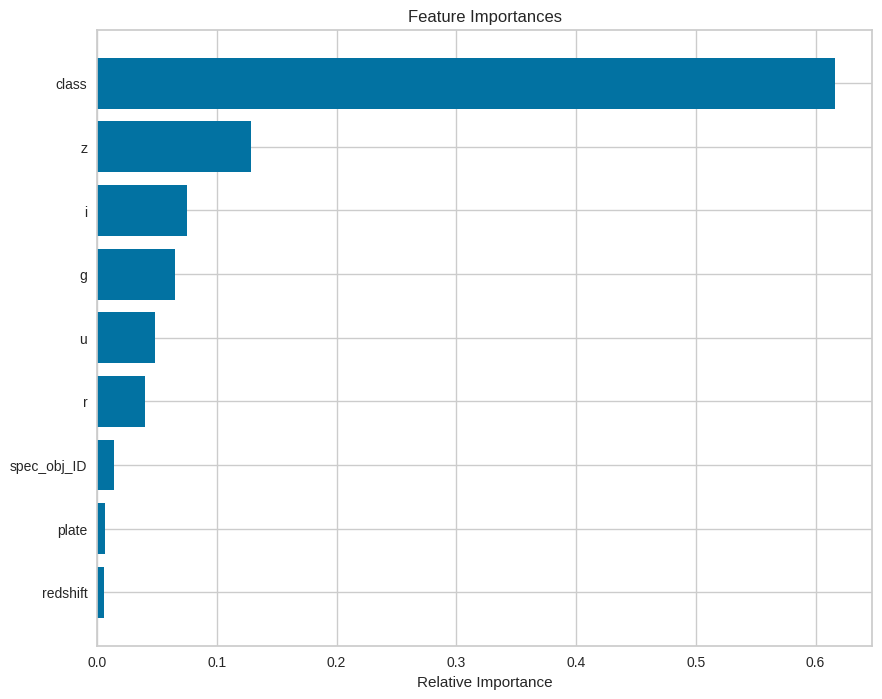

The five most discriminating photometric features according to the bar chart are: Class, z:Infrared Filter, i:Near Infrared Filter, g:Green Filter, u:Ultraviolet Filter


In [50]:
features = df.columns
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,8))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

print(f'The five most discriminating photometric features according to the bar chart are: Class, z:Infrared Filter, i:Near Infrared Filter, g:Green Filter, u:Ultraviolet Filter')